# スイング反応器シミュレーター — ランダム 100 ケース動作確認

物理的にあり得る範囲でランダムサンプリングした 100 条件でシミュレーションを実行し、  
現状の挙動（正常・ペナルティ返却・例外）を可視化する。

| パラメータ | サンプリング範囲 |
|---|---|
| `T_in` | 500〜700 °C（773〜973 K）|
| `z_cat` | 1〜12 m |
| `t_cyc` | 3〜30 min |
| `D` | 0.5〜4 m |
| `F_in[C3H8]` | 50〜200 kmol/h |
| `T_feed` | 25〜127 °C（298〜400 K）|
| `P_in` | 0.8〜2.5 bar |

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.swing_reactor_simulator import (
    DesignVars, FeedStream, FixedParams, simulate_swing_reactor_system
)

In [2]:
N = 100
rng = np.random.default_rng(42)

# ランダムサンプリング（物理的にあり得る範囲）
T_in_arr   = rng.uniform(773.15, 973.15, N)   # 500〜700 °C [K]
z_cat_arr  = rng.uniform(1.0,   12.0,   N)    # [m]
t_cyc_arr  = rng.uniform(3.0,   30.0,   N)    # [min]
D_arr      = rng.uniform(0.5,    4.0,   N)    # [m]
F_A_arr    = rng.uniform(50.0, 200.0,   N)    # C3H8 [kmol/h]
T_feed_arr = rng.uniform(298.15, 400.0, N)    # [K]
P_in_arr   = rng.uniform(0.8e5, 2.5e5,  N)    # [Pa]

fixed = FixedParams()
results = []

for i in range(N):
    design = DesignVars(
        T_in=float(T_in_arr[i]),
        z_cat=float(z_cat_arr[i]),
        t_cyc=float(t_cyc_arr[i]),
        D=float(D_arr[i]),
    )
    feed = FeedStream(
        F_in={
            'C3H8': float(F_A_arr[i]),
            'C3H6': 0.0, 'H2': 0.0, 'C2H4': 0.0, 'CH4': 0.0, 'C2H6': 0.0,
        },
        T_feed=float(T_feed_arr[i]),
        P_in=float(P_in_arr[i]),
    )

    status = 'ok'
    conv = sel = t_out = q_ph = capex = np.nan
    error_msg = ''

    try:
        r = simulate_swing_reactor_system(design, feed, fixed)
        conv  = r.performance.Conversion
        sel   = r.performance.Selectivity
        t_out = r.effluent.T_out_avg
        q_ph  = r.effluent.Q_preheat
        capex = r.equipment.Reactor_CAPEX
        if capex >= 1e9:
            status = 'penalty'
    except Exception as e:
        status    = 'error'
        error_msg = f'{type(e).__name__}: {e}'

    results.append({
        'i':           i,
        'T_in_C':      T_in_arr[i] - 273.15,
        'z_cat':       z_cat_arr[i],
        't_cyc':       t_cyc_arr[i],
        'D':           D_arr[i],
        'F_A':         F_A_arr[i],
        'P_in_bar':    P_in_arr[i] / 1e5,
        'status':      status,
        'Conversion':  conv,
        'Selectivity': sel,
        'T_out_C':     t_out - 273.15 if not np.isnan(t_out) else np.nan,
        'Q_preheat':   q_ph,
        'error_msg':   error_msg,
    })

    if (i + 1) % 10 == 0:
        print(f'{i+1:3d}/100 完了')

print('\n完了')

 10/100 完了
 20/100 完了
 30/100 完了
 40/100 完了
 50/100 完了
 60/100 完了
 70/100 完了
 80/100 完了
 90/100 完了
100/100 完了

完了


In [3]:
df = pd.DataFrame(results)

print('=== ステータス別件数 ===')
print(df['status'].value_counts().to_string())
print()

df_ok = df[df['status'] == 'ok'].copy()
print(f'=== 正常ケース（{len(df_ok)} 件）の統計 ===')
print(df_ok[['Conversion', 'Selectivity', 'T_out_C', 'Q_preheat']].describe().round(2).to_string())

df_err = df[df['status'] == 'error']
if len(df_err) > 0:
    print()
    print('=== エラーケース一覧 ===')
    print(df_err[['i', 'T_in_C', 'z_cat', 't_cyc', 'D', 'error_msg']].to_string())

=== ステータス別件数 ===
status
ok    100

=== 正常ケース（100 件）の統計 ===
       Conversion  Selectivity  T_out_C  Q_preheat
count      100.00       100.00   100.00     100.00
mean        30.61        93.82   360.50       8.31
std          7.82         9.25    86.95       3.16
min          4.36        60.14   194.46       2.69
25%         27.42        94.25   291.27       5.33
50%         30.38        97.56   353.76       8.26
75%         34.70        99.37   423.49      10.82
max         52.07        99.85   578.76      14.78


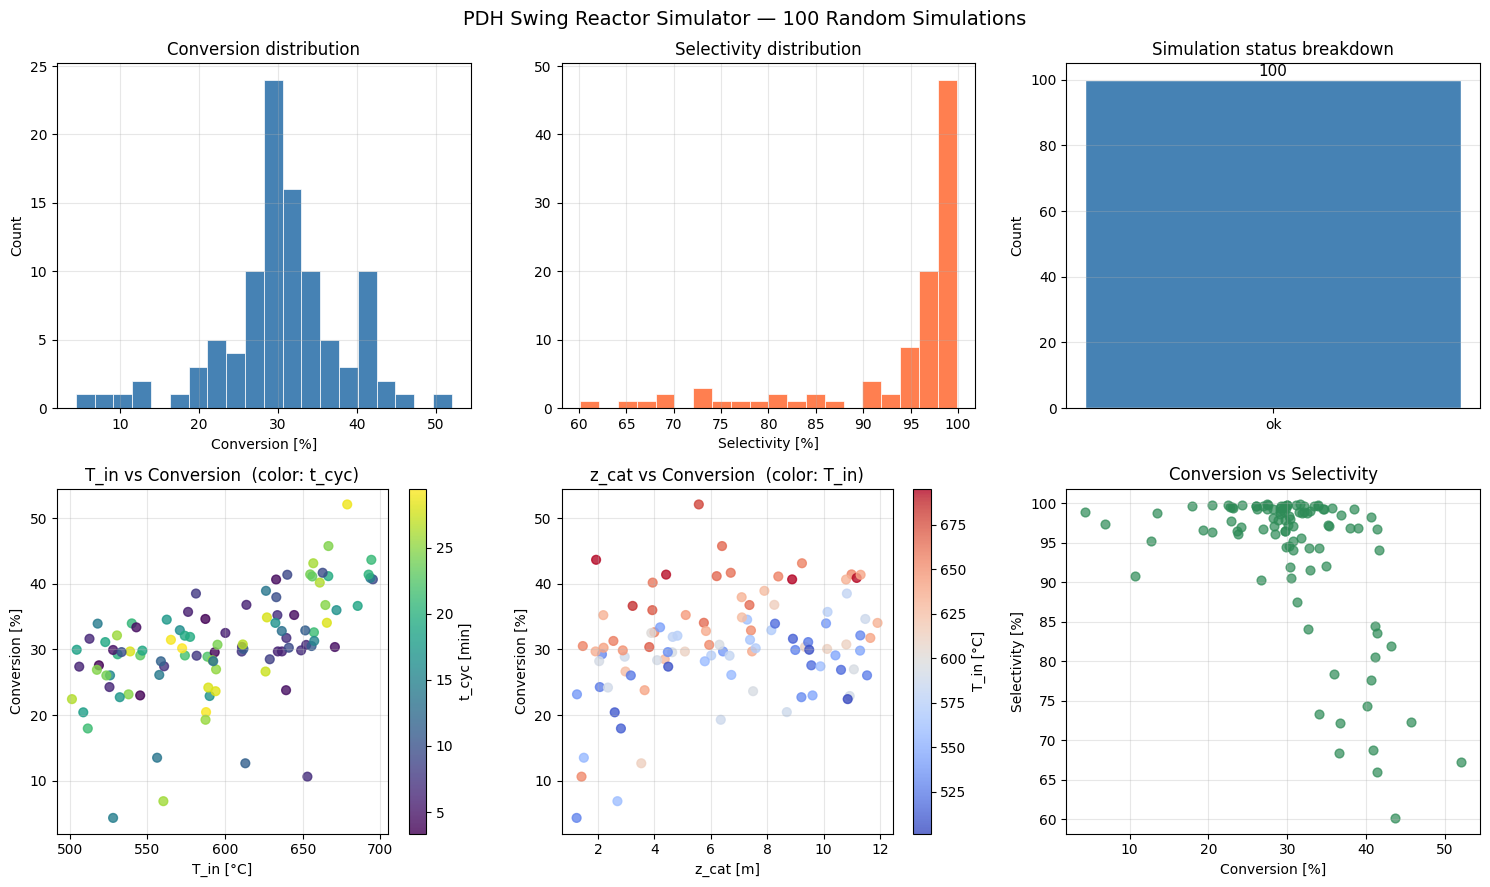

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('PDH Swing Reactor Simulator — 100 Random Simulations', fontsize=14)

STATUS_COLORS = {'ok': 'steelblue', 'penalty': 'orange', 'error': 'crimson'}

# (0,0) Conversion 分布
axes[0, 0].hist(df_ok['Conversion'].dropna(), bins=20,
                color='steelblue', edgecolor='white', linewidth=0.5)
axes[0, 0].set_xlabel('Conversion [%]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Conversion distribution')
axes[0, 0].grid(True, alpha=0.3)

# (0,1) Selectivity 分布
axes[0, 1].hist(df_ok['Selectivity'].dropna(), bins=20,
                color='coral', edgecolor='white', linewidth=0.5)
axes[0, 1].set_xlabel('Selectivity [%]')
axes[0, 1].set_title('Selectivity distribution')
axes[0, 1].grid(True, alpha=0.3)

# (0,2) ステータス内訳
status_counts = df['status'].value_counts()
bar_colors = [STATUS_COLORS.get(s, 'gray') for s in status_counts.index]
bars = axes[0, 2].bar(status_counts.index, status_counts.values,
                      color=bar_colors, edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    axes[0, 2].text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3, str(val),
                    ha='center', va='bottom', fontsize=11)
axes[0, 2].set_title('Simulation status breakdown')
axes[0, 2].set_ylabel('Count')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# (1,0) T_in vs Conversion（t_cyc で色付け）
sc = axes[1, 0].scatter(
    df_ok['T_in_C'], df_ok['Conversion'],
    c=df_ok['t_cyc'], cmap='viridis', s=40, alpha=0.8
)
plt.colorbar(sc, ax=axes[1, 0], label='t_cyc [min]')
axes[1, 0].set_xlabel('T_in [°C]')
axes[1, 0].set_ylabel('Conversion [%]')
axes[1, 0].set_title('T_in vs Conversion  (color: t_cyc)')
axes[1, 0].grid(True, alpha=0.3)

# (1,1) z_cat vs Conversion（T_in で色付け）
sc2 = axes[1, 1].scatter(
    df_ok['z_cat'], df_ok['Conversion'],
    c=df_ok['T_in_C'], cmap='coolwarm', s=40, alpha=0.8
)
plt.colorbar(sc2, ax=axes[1, 1], label='T_in [°C]')
axes[1, 1].set_xlabel('z_cat [m]')
axes[1, 1].set_ylabel('Conversion [%]')
axes[1, 1].set_title('z_cat vs Conversion  (color: T_in)')
axes[1, 1].grid(True, alpha=0.3)

# (1,2) Conversion vs Selectivity
axes[1, 2].scatter(
    df_ok['Conversion'], df_ok['Selectivity'],
    alpha=0.7, color='seagreen', s=40
)
axes[1, 2].set_xlabel('Conversion [%]')
axes[1, 2].set_ylabel('Selectivity [%]')
axes[1, 2].set_title('Conversion vs Selectivity')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()